In [27]:
# 텍스트 전처리
import os
import json

def preprocess_text_from_json_files(input_folder, output_folder):
    """
    Processes all JSON files in a folder, replacing 'form' in 'text' with 'originalForm'
    from 'expression', and saves the preprocessed text to separate text files.

    Args:
        input_folder (str): Path to the folder containing JSON files.
        output_folder (str): Path to the folder where processed text files will be saved.
    """
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Process each JSON file in the input folder
    for file_name in os.listdir(input_folder):
        if file_name.endswith(".json"):
            input_file_path = os.path.join(input_folder, file_name)
            output_file_path = os.path.join(output_folder, file_name.replace(".json", "_processed.txt"))

            with open(input_file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            # List to store the processed texts for this file
            processed_texts = []

            for dialog in data.get("dialogs", []):
                if "text" in dialog and "expression" in dialog:
                    text = dialog["text"]
                    expressions = dialog["expression"]

                    # Replace 'form' with 'originalForm' in the text
                    for expr in expressions:
                        form = expr.get("form", "")
                        original_form = expr.get("originalForm", "")
                        if form and original_form:
                            text = text.replace(form, original_form)

                    # Append the processed text
                    processed_texts.append(text)

            # Save the processed texts to a text file
            with open(output_file_path, 'w', encoding='utf-8') as f:
                for text in processed_texts:
                    f.write(text + "\n")

            print(f"Processed {file_name} -> {output_file_path}")

# Example usage
input_folder = r"C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\과학기술(텍스트)"  # Replace with the folder containing JSON files
output_folder = r"C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된"  # Replace with the folder to save processed files

preprocess_text_from_json_files(input_folder, output_folder)



Processed m1_1_50_f2_1_46_211222_0024152.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된\m1_1_50_f2_1_46_211222_0024152_processed.txt
Processed m1_1_50_f2_1_46_211225_0026690.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된\m1_1_50_f2_1_46_211225_0026690_processed.txt
Processed m1_1_50_f2_1_46_211225_0026691.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된\m1_1_50_f2_1_46_211225_0026691_processed.txt
Processed m1_1_50_f2_1_46_211225_0026701.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된\m1_1_50_f2_1_46_211225_0026701_processed.txt
Processed m1_1_50_f2_1_46_211225_0026710.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(텍스트)\처리된\m1_1_50_f2_1_46_211225_0026710_processed.txt
Processed m1_1_50_f2_1_46_211225_0026714.json -> C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preproce

In [25]:
import os
import subprocess

def convert_pcm_to_wav(pcm_file_path, output_path):
    try:
        # FFmpeg 명령어로 PCM 파일을 WAV로 변환 (자동으로 샘플링 주파수 추정)
        ffmpeg_command = [
            'ffmpeg', 
            '-f', 's16le',          # PCM 포맷 (16비트, 리틀 엔디안)
            '-ar', '16000',         # 샘플링 주파수 16000Hz
            '-ac', '1',             # 모노 (1채널)
            '-i', pcm_file_path,    # 입력 PCM 파일 경로
            output_path             # 출력 WAV 파일 경로
        ]
        
        # FFmpeg 실행
        subprocess.run(ffmpeg_command, check=True)
        print(f"파일 변환 완료: {output_path}")
        
    except subprocess.CalledProcessError as e:
        print(f"변환 중 오류 발생: {e}")
        

def convert_all_pcm_in_folder(folder_path, output_folder):
    os.makedirs(output_folder, exist_ok=True)  # 출력 폴더가 없으면 생성
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".pcm"):
            pcm_file_path = os.path.join(folder_path, file_name)
            
            # 출력 폴더 내 경로 설정
            output_path = os.path.join(output_folder, file_name.replace(".pcm", ".wav"))
            
            # PCM 파일을 WAV로 변환
            convert_pcm_to_wav(pcm_file_path, output_path)

# 폴더 경로 설정
folder_path = r"C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)"
output_folder = r"C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된"  # 원하는 출력 폴더 경로 설정

# 변환 함수 호출
convert_all_pcm_in_folder(folder_path, output_folder)

파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211222_0024152.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026690.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026691.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026701.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026710.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026714.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211225_0026729.wav
파일 변환 완료: C:\Users\MATH-3\Downloads\preprocess-20241202T075613Z-001\preprocess\인간관계(음성)\처리된\m1_1_50_f2_1_46_211

In [57]:
import os

def create_speech_recognition_dataset(audio_folder, text_folder, output_file):
    dataset = []  # 데이터셋을 저장할 리스트
    
    # 오디오 폴더 내 모든 .wav 파일을 처리
    for audio_file in os.listdir(audio_folder):
        if audio_file.endswith(".wav"):
            # 텍스트 파일 이름이 오디오 파일과 동일해야 하므로, 확장자만 제외한 파일 이름을 추출
            base_name = os.path.splitext(audio_file)[0]
            
            # 해당 오디오 파일과 동일한 이름의 텍스트 파일 찾기
            text_file = f"{base_name}.txt"
            text_file_path = os.path.join(text_folder, text_file)
            
            # 텍스트 파일이 존재하는지 확인
            if os.path.exists(text_file_path):
                # 텍스트 파일 내용 읽기
                try:
                    with open(text_file_path, 'r', encoding='utf-8') as f:
                        transcription = f.read().strip()
                    # 읽은 내용 출력 (디버깅용)
                    print(f"텍스트 파일 내용: {transcription}")
                    
                    # 텍스트가 비어있지 않으면 데이터셋에 추가
                    if transcription:
                        audio_file_path = os.path.join(audio_folder, audio_file)
                        dataset.append((audio_file_path, transcription))
                    else:
                        print(f"텍스트 파일이 비어 있음: {text_file_path}")
                except Exception as e:
                    print(f"텍스트 파일 읽기 오류: {e}")
            else:
                print(f"해당 오디오 파일에 맞는 텍스트 파일 없음: {text_file_path}")
    
    # 결과를 파일로 저장 (예: CSV 형식으로 저장)
    if dataset:
        with open(output_file, 'w', encoding='utf-8') as f:
            for audio_path, text in dataset:
                f.write(f"{audio_path},{text}\n")  # 음성 파일 경로와 텍스트를 콤마로 구분하여 저장
        print(f"데이터셋 생성 완료: {output_file}")
    else:
        print(f"데이터셋에 항목이 없어서 파일이 생성되지 않았습니다.")

# 폴더 경로 설정
audio_folder = r"C:\Users\MATH-3\Downloads\data\음성\인간관계"  # WAV 파일이 있는 폴더
text_folder = r"C:\Users\MATH-3\Downloads\data\텍스트\인간관계"  # 텍스트 파일이 있는 폴더
output_file = r"C:\Users\MATH-3\Downloads\data\output.csv"  # 결과로 저장할 파일 경로

# 데이터셋 생성 함수 호출
create_speech_recognition_dataset(audio_folder, text_folder, output_file)


텍스트 파일 내용: 그런데 좀 아타깝지 않아 나는 우리나라 프리챌이 facebook보다 더 빨리 개발되었던 것 같은데. 나도 그래 사실 우리나라 아이러브 스쿨이 facebook보다 2년인가 빨랐다는데 이런 결과는 우리나라 사람들의 사회지향성과 창의성이 반영된 것 같은데 글로벌화되지 못해 아쉬워. 이런 사회지향성과 창의성은 1인media가 활성화되는 계기가되어 플랫폼을 자유롭게 이용하고 소통의 공간으로 사용하면서 1인 마켓이라는 세포마켓도 활성화되고 있데. 그런데 저번에 뉴스에서 telegram이라는 용어가 나오던데 뭐야. telegram은 오픈소스 인터넷 모바일 메신저야 우라나라의 카카오톡과 비슷한 거지. 그런데 telegram은 비밀대화기능을 가지고 있는데 이것은 각종 암호화를 적용해서 해킹이 불가능하대 아주 중요한 기밀을 유지하는데 사용할 수 있겠지 그래서 범죄에 사용될 소지가 있지. 최근에 밀접접촉자로 통보 받아서 약 2주 정도 자가격리를 했더니 기분이 down됐어. 하루 종일 home에만 갇혀 지내면 얼마나 답답하고 힘들었을까. 우리 company 동료 중 증세가 있었는데 출근하는 바람에 많은 사람들이 자가격리를 했어. 2주 동안 패밀리랑 friends도 못보고 아무것도 하지 못했는데 뭐하면서 지냈니? 사람들과 대면하며 커뮤니케이션을 하는 걸 좋아하는데 못하게 되니까 tension도 떨어지고 입맛도 사라졌어. 나라도 2주 동안 프리즌처럼 갇혀 지내면 home이라 할지라도 창살 없는 감옥처럼 느껴질 것 같아. 친구의 instagram을 보니까 얼마전에 베이비샤워를 했더라. 오 home party 형식으로 꾸며서 그렇게 한거야? 응 hotel에 놀러가서 아기자게 꾸며놓고 사진 찍었더라. 내가 그래서 SNS를 잘 안해 괜히 비교되는 것 같아서 싫고. 친구랑 사귄지 3년 정도 됐는데 젠리라는 위치 공유 application을 설치했어. 나도 친구랑 비트원 application도 설치했는데 젠리는 처음 들어봐. 서로의 위치를 GPS 기반으로 공유 받을 수 있어.

In [3]:
import whisper
import jiwer
import pandas as pd
from tqdm import tqdm  # tqdm 임포트

# Whisper 모델 로드
model = whisper.load_model("base")  # 필요에 따라 모델 크기 변경 가능

# CSV 파일 경로 지정
csv_file_path = r"C:\Users\MATH-3\Downloads\data\human_dataset.csv"

# 첫 번째 ','만 구분자로 사용하도록 정규표현식 적용
df = pd.read_csv(csv_file_path, header=None, delimiter=r',(?=\S)', engine='python')

# 첫 번째 두 열을 확인
print(df.head())

# WER 계산을 위한 함수
def calculate_wer(reference, hypothesis):
    return jiwer.wer(reference, hypothesis)

# 결과 저장용 리스트
results = []

# 결과 저장 파일 경로
output_file_path = r"C:\Users\MATH-3\Downloads\data\results.csv"

# CSV 파일에서 오디오 파일 경로와 참조 텍스트 추출
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Audio Files"):
    audio_file_path = row[0]  # 첫 번째 열이 음성 파일 경로
    reference_text = row[1]   # 두 번째 열이 참조 텍스트

    try:
        # Whisper를 사용하여 오디오 파일에서 텍스트 추출
        result = model.transcribe(audio_file_path)
        hypothesis_text = result['text']

        # WER 계산
        wer = calculate_wer(reference_text, hypothesis_text)

        # 결과 저장
        results.append({
            'audio_file': audio_file_path,
            'reference_text': reference_text,
            'hypothesis_text': hypothesis_text,
            'WER': wer
        })

        # 작업 중간에 결과를 파일로 저장
        pd.DataFrame(results).to_csv(output_file_path, index=False, mode='w', header=True)

    except Exception as e:
        print(f"Error processing {audio_file_path}: {e}")

# 최종 결과 저장
pd.DataFrame(results).to_csv(output_file_path, index=False)
print(f"Results saved to {output_file_path}")


C:\Users\MATH-3\anaconda3\Lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_location=device)


                                                   0  \
0  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
1  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
2  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
3  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
4  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   

                                                   1  
0  그런데 좀 아타깝지 않아 나는 우리나라 프리챌이 facebook보다 더 빨리 개발되...  
1  Reels가 뭐야? 아 처음들어봐 릴스가 살짝 Tik tok이랑 비슷한데 인스타에서...  
2  그게 뭐야 home training가 무슨 재미야 나랑 폴댄스 하러 가자니까. 폴댄...  
3  유형에 따라서 reaction이 싫다 좋다 서로 상극이다 노잼이다 등. 우리는 나이...  
4  어느정도 인과관계가 입증되고 그 안에서 스토리를 만들어 낼 수 있다면 challen...  


Processing Audio Files:   0%|                                                                  | 0/284 [00:00<?, ?it/s]C:\Users\MATH-3\anaconda3\Lib\site-packages\whisper\transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
Processing Audio Files: 100%|██████████████████████████████████████████████████████| 284/284 [3:14:01<00:00, 40.99s/it]IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)




In [23]:
from safetensors.torch import load_file
import torch
import pandas as pd
from tqdm import tqdm
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import librosa
import jiwer

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 및 프로세서 로드
model_name = "openai/whisper-base"
processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Safetensors 파일 로드
adapter_path = r"C:\Users\MATH-3\Downloads\adapter_model.safetensors"
adapter_weights = load_file(adapter_path)  # Safetensors 가중치 로드
model.load_state_dict(adapter_weights, strict=False)  # 모델에 가중치 로드

# 모델을 GPU로 이동
model = model.to(device)
model.eval()

# 첫 번째 ','만 구분자로 사용하도록 정규표현식 적용
df = pd.read_csv(csv_file_path, header=None, delimiter=r',(?=\S)', engine='python')

# 첫 번째 두 열을 확인
print(df.head())

# WER 계산을 위한 함수
def calculate_wer(reference, hypothesis):
    return jiwer.wer(reference, hypothesis)

import torchaudio

# 오디오 파일에서 텍스트 추출을 위한 함수
def transcribe_audio(audio_file_path, model, processor, device):
    # 오디오 파일 로드
    audio, sr = librosa.load(audio_file_path, sr=16000)  # Whisper는 16kHz 샘플링 속도를 사용
    audio_tensor = torch.tensor(audio).unsqueeze(0).to(device)

    # 전처리
    input_features = processor.feature_extractor(audio_tensor.cpu().numpy(), sampling_rate=16000, return_tensors="pt").input_features.to(device)

    # 모델 추론
    predicted_ids = model.generate(input_features)

    # 텍스트 후처리
    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    return transcription

# 결과 저장용 리스트
results = []

# 결과 저장 파일 경로
output_file_path = r"C:\Users\MATH-3\Downloads\data\흠...results.csv"

# CSV 파일에서 오디오 파일 경로와 참조 텍스트 추출
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Audio Files"):
    audio_file_path = row[0]  # 첫 번째 열이 음성 파일 경로
    reference_text = row[1]   # 두 번째 열이 참조 텍스트

    try:
        # Whisper를 사용하여 오디오 파일에서 텍스트 추출
        hypothesis_text = transcribe_audio(audio_file_path, model, processor, device)

        # WER 계산
        wer = calculate_wer(reference_text, hypothesis_text)

        # 결과 저장
        results.append({
            'audio_file': audio_file_path,
            'reference_text': reference_text,
            'hypothesis_text': hypothesis_text,
            'WER': wer
        })

        # 작업 중간에 결과를 파일로 저장
        pd.DataFrame(results).to_csv(output_file_path, index=False, mode='w', header=True)

    except Exception as e:
        print(f"Error processing {audio_file_path}: {e}")

# 최종 결과 저장
pd.DataFrame(results).to_csv(output_file_path, index=False)
print(f"Results saved to {output_file_path}")

                                                   0  \
0  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
1  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
2  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
3  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
4  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   

                                                   1  
0  그런데 좀 아타깝지 않아 나는 우리나라 프리챌이 facebook보다 더 빨리 개발되...  
1  Reels가 뭐야? 아 처음들어봐 릴스가 살짝 Tik tok이랑 비슷한데 인스타에서...  
2  그게 뭐야 home training가 무슨 재미야 나랑 폴댄스 하러 가자니까. 폴댄...  
3  유형에 따라서 reaction이 싫다 좋다 서로 상극이다 노잼이다 등. 우리는 나이...  
4  어느정도 인과관계가 입증되고 그 안에서 스토리를 만들어 낼 수 있다면 challen...  


Processing Audio Files:   0%|                                                                  | 0/284 [00:00<?, ?it/s]Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Processing Audio Files: 100%|████████████████████████

Results saved to C:\Users\MATH-3\Downloads\data\흠...results.csv


In [7]:
import whisper
import jiwer
import pandas as pd
from tqdm import tqdm
import torch

# GPU 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# Whisper 모델 로드
model = whisper.load_model("base", device=device)  # 모델을 GPU 또는 CPU로 로드

# CSV 파일 경로 지정
csv_file_path = r"C:\Users\MATH-3\Downloads\data\human_dataset.csv"

# 첫 번째 ','만 구분자로 사용하도록 정규표현식 적용
df = pd.read_csv(csv_file_path, header=None, delimiter=r',(?=\S)', engine='python')

# 첫 번째 두 열을 확인
print(df.head())

# WER 계산을 위한 함수
def calculate_wer(reference, hypothesis):
    return jiwer.wer(reference, hypothesis)

# 결과 저장용 리스트
results = []

# 결과 저장 파일 경로
output_file_path = r"C:\Users\MATH-3\Downloads\data\results.csv"

# CSV 파일에서 오디오 파일 경로와 참조 텍스트 추출
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Audio Files"):
    audio_file_path = row[0]  # 첫 번째 열이 음성 파일 경로
    reference_text = row[1]   # 두 번째 열이 참조 텍스트

    try:
        # Whisper를 사용하여 오디오 파일에서 텍스트 추출
        result = model.transcribe(audio_file_path)
        hypothesis_text = result['text']

        # WER 계산
        wer = calculate_wer(reference_text, hypothesis_text)

        # 결과 저장
        results.append({
            'audio_file': audio_file_path,
            'reference_text': reference_text,
            'hypothesis_text': hypothesis_text,
            'WER': wer
        })

        # 작업 중간에 결과를 파일로 저장
        pd.DataFrame(results).to_csv(output_file_path, index=False, mode='w', header=True)

    except Exception as e:
        print(f"Error processing {audio_file_path}: {e}")

# 최종 결과 저장
pd.DataFrame(results).to_csv(output_file_path, index=False)
print(f"Results saved to {output_file_path}")


C:\Users\MATH-3\anaconda3\Lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_location=device)


                                                   0  \
0  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
1  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
2  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
3  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   
4  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   

                                                   1  
0  그런데 좀 아타깝지 않아 나는 우리나라 프리챌이 facebook보다 더 빨리 개발되...  
1  Reels가 뭐야? 아 처음들어봐 릴스가 살짝 Tik tok이랑 비슷한데 인스타에서...  
2  그게 뭐야 home training가 무슨 재미야 나랑 폴댄스 하러 가자니까. 폴댄...  
3  유형에 따라서 reaction이 싫다 좋다 서로 상극이다 노잼이다 등. 우리는 나이...  
4  어느정도 인과관계가 입증되고 그 안에서 스토리를 만들어 낼 수 있다면 challen...  


Processing Audio Files: 100%|██████████████████████████████████████████████████████| 284/284 [1:12:31<00:00, 15.32s/it]

Results saved to C:\Users\MATH-3\Downloads\data\results.csv


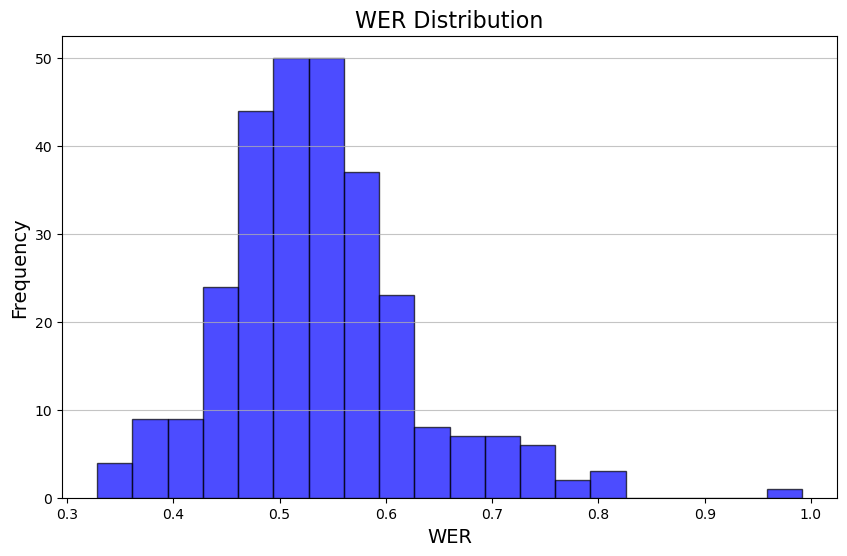

Mean WER: 0.5380
Median WER: 0.5288
Standard Deviation of WER: 0.0908

Top 5 highest WER samples:
                                            audio_file  \
247  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_2_26...   
250  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_2_26...   
262  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_2_26...   
265  C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_2_26...   
24   C:\Users\MATH-3\Downloads\data\음성\인간관계\m1_1_50...   

                                        reference_text  \
247  사실 marriage를 하고 싶은 사람은 있어. 그럼 하면 되지 허니문은 Hawai...   
250  제주통갈치랑 회 전복 인스타맛집 찾아갔쥐 view도 좋더라. 즐찾해놓고 다가보고싶었...   
262  제주통갈치랑 회 전복 인스타맛집 찾아갔쥐 view도 좋더라. 즐찾해놓고 다가보고싶었...   
265  좋아 그런데 우리 아이 얼집 생일party 준비해야해서 요즘 핫한 육아템 있어서 답...   
24   인생에서 제일 아름답고 행복한 best 순간인것 같아서. variety한 소스들을 ...   

                                       hypothesis_text       WER  
247   네. 사실 메디를 하고 싶은 사람은 있어. 그럼 하면 되지. 허니문은 하와이가 좋...  0.991347  
250   TTT 일단 태놓고 아 가보고 싶었는데 베이비 때문에 말이 못 갔어. 요즘 TV에...  0.807692  
262

C:\Users\MATH-3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\MATH-3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\MATH-3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\MATH-3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\MATH-3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

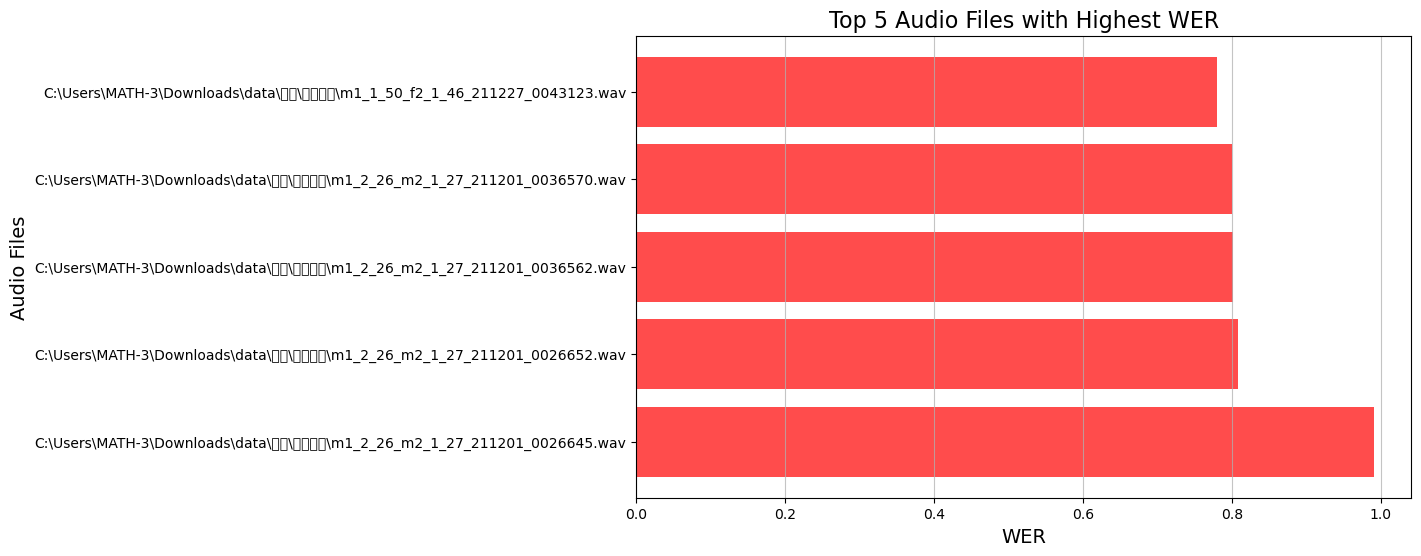

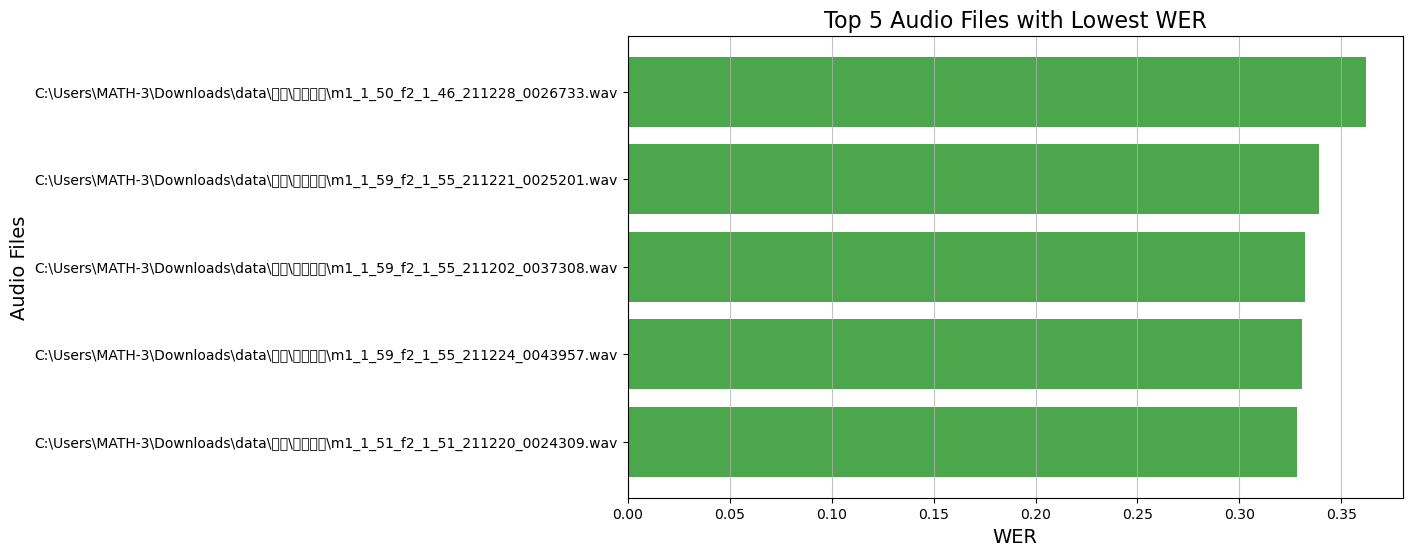

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 결과 파일 경로
output_file_path = r"C:\Users\MATH-3\Downloads\data\results.csv"

# CSV 파일 읽기
df = pd.read_csv(output_file_path)

# WER 분포를 히스토그램으로 시각화
plt.figure(figsize=(10, 6))
plt.hist(df['WER'], bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('WER Distribution', fontsize=16)
plt.xlabel('WER', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

# WER의 기초 통계 확인
wer_mean = df['WER'].mean()
wer_median = df['WER'].median()
wer_std = df['WER'].std()

print(f"Mean WER: {wer_mean:.4f}")
print(f"Median WER: {wer_median:.4f}")
print(f"Standard Deviation of WER: {wer_std:.4f}")

# 상위 5개의 높은 WER 항목 확인
high_wer_samples = df.nlargest(5, 'WER')
print("\nTop 5 highest WER samples:")
print(high_wer_samples)

# 상위 5개의 낮은 WER 항목 확인
low_wer_samples = df.nsmallest(5, 'WER')
print("\nTop 5 lowest WER samples:")
print(low_wer_samples)

# 상위 5개 WER 높은 오디오 파일 시각화
plt.figure(figsize=(10, 6))
plt.barh(high_wer_samples['audio_file'], high_wer_samples['WER'], color='red', alpha=0.7)
plt.title('Top 5 Audio Files with Highest WER', fontsize=16)
plt.xlabel('WER', fontsize=14)
plt.ylabel('Audio Files', fontsize=14)
plt.grid(axis='x', alpha=0.75)
plt.show()

# 상위 5개 WER 낮은 오디오 파일 시각화
plt.figure(figsize=(10, 6))
plt.barh(low_wer_samples['audio_file'], low_wer_samples['WER'], color='green', alpha=0.7)
plt.title('Top 5 Audio Files with Lowest WER', fontsize=16)
plt.xlabel('WER', fontsize=14)
plt.ylabel('Audio Files', fontsize=14)
plt.grid(axis='x', alpha=0.75)
plt.show()


In [7]:
import re
import pandas as pd
from transformers import MarianTokenizer, MarianMTModel
from tqdm import tqdm
import torch

# GPU 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 번역 모델 로드
model_name = "Helsinki-NLP/opus-mt-ko-en"
trans_tokenizer = MarianTokenizer.from_pretrained(model_name)
trans_model = MarianMTModel.from_pretrained(model_name).to(device)  # 모델을 GPU로 이동

# 한국어-영어 코드스위칭 번역 함수
def translate_korean_phrases(text):
    # 영어 기준으로 분리
    phrases = re.split(r'([a-zA-Z0-9]+)', text)
    translated_phrases = []

    for phrase in phrases:
        if re.search(r'[가-힣]', phrase):  # 한국어가 포함된 구문
            # 번역 수행
            inputs = trans_tokenizer(phrase, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = trans_model.generate(**inputs)
            translated_phrase = trans_tokenizer.decode(outputs[0], skip_special_tokens=True)
            translated_phrases.append(translated_phrase)
        else:
            # 영어 구문이나 기타 문장은 그대로 유지
            translated_phrases.append(phrase)

    # 공백만 있는 요소 제거
    translated_phrases = [phrase for phrase in translated_phrases if phrase.strip()]

    # 번역된 구문 결합
    return ' '.join(translated_phrases)

# CSV 파일 읽기
input_csv_path = r"C:\Users\MATH-3\Downloads\data\translate_source.csv"  # 입력 CSV 파일 경로
output_csv_path = r"C:\Users\MATH-3\Downloads\data\output_translated_gpu.csv"  # 번역 결과를 저장할 CSV 파일 경로

# CSV 파일 로드
df = pd.read_csv(input_csv_path)

# 열 이름 확인 및 텍스트 변환 수행
if len(df.columns) < 2:
    raise ValueError("CSV 파일에 두 번째 열(column2)이 없습니다.")

# tqdm를 사용하여 진행 상황 표시
tqdm.pandas(desc="Translating column2 on GPU")
df['translated_text'] = df.iloc[:, 1].progress_apply(translate_korean_phrases)  # 두 번째 열 번역 수행

# 결과 저장
df.to_csv(output_csv_path, index=False)
print(f"Translated CSV saved to {output_csv_path}")


Using device: cuda


Translating column2 on GPU: 100%|██████████████████████████████████████████████████| 284/284 [1:30:12<00:00, 19.06s/it]

Translated CSV saved to C:\Users\MATH-3\Downloads\data\output_translated_gpu.csv
